In [54]:
# Ques. 1
# In the given dataset TVMarketing.csv you have given  sales based on 'TV' marketing budget.
# Build a linear regression model to predict 'Sales' using 'TV' as the predictor variable. Also plot regression line.

# Dataset : TVMarketing.csv

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df1 = pd.read_csv("TvMarketing.csv")
df1.head(2)

,TV,Sales
0,230.1,22.1
1,44.5,10.4


In [57]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [58]:
df1.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [59]:
df1.isna().sum()

TV       0
Sales    0
dtype: int64

In [60]:
df1.corr()

,TV,Sales
TV,1.000000,0.782224
Sales,0.782224,1.000000


In [61]:
x=df1.drop('Sales',axis=1)
y=df1['Sales']

In [62]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [63]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
y_pred = model.predict(x_test)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# predict all the training set values
y_pred_train = model.predict(x_train)

# calculate all the evaluation metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"mean absolute error: {mae_train:.2f}")
print(f"mean absolute percentage error: {mape_train:.2f}")
print(f"mean squared error: {mse_train:.2f}")
print(f"root mean squared error: {rmse_train:.2f}")
print(f"r2 score: {r2_train:.2f}")

mean absolute error: 2.58
mean absolute percentage error: 0.21
mean squared error: 10.60
root mean squared error: 3.26
r2 score: 0.59


In [66]:
# predict all the training set values
y_pred = model.predict(x_test)

# calculate all the evaluation metrics
mae_test = mean_absolute_error(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = root_mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"mean absolute error: {mae_test:.2f}")
print(f"mean absolute percentage error: {mape_test:.2f}")
print(f"mean squared error: {mse_test:.2f}")
print(f"root mean squared error: {rmse_test:.2f}")
print(f"r2 score: {r2_test:.2f}")

mean absolute error: 2.44
mean absolute percentage error: 0.19
mean squared error: 10.20
root mean squared error: 3.19
r2 score: 0.68


In [67]:
report = pd.DataFrame({
    "MAE": [mae_train, mae_test],
    "MAPE": [mape_train, mape_test],
    "MSE": [mse_train, mse_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
}, index=["Training", "Testing"])
report

,MAE,MAPE,MSE,RMSE,R2
Training,2.583084,0.210795,10.603601,3.256317,0.591167
Testing,2.444420,0.186687,10.204654,3.194472,0.676695


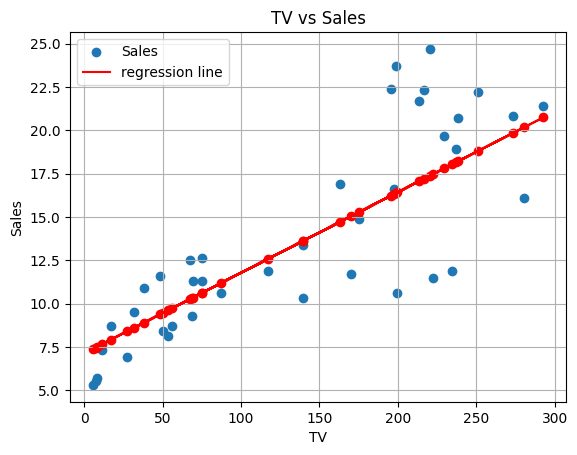

In [68]:
plt.scatter(x_test, y_test, label="Sales")

# add the regression line used in train dataset
plt.plot(x_test, y_pred, label="regression line", color="red")
plt.scatter(x_test, y_pred, color="red")

plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.grid()
plt.legend()

In [69]:
# Que. 2
# You own an ice cream business and you would like to create a model that could predict the daily revenue in dollars based on the outside air temperature (degC). Build Linear Regression Model and plot regression line.

# Dataset : IceCreamData.csv

In [70]:
df2 = pd.read_csv('IceCreamData.csv')
df2.head(2)

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122


In [71]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [72]:
df2.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [73]:
df2.corr()

,Temperature,Revenue
Temperature,1.000000,0.989802
Revenue,0.989802,1.000000


In [74]:
x1=df2.drop('Revenue',axis=1)
y1=df2['Revenue']

In [75]:
from sklearn.model_selection import train_test_split
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,train_size=0.8,random_state=42)

In [76]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x1_train,y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
y1_pred = model.predict(x1_test)

In [78]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# predict all the training set values
y1_pred_train = model.predict(x1_train)

# calculate all the evaluation metrics
mae_train = mean_absolute_error(y1_train, y1_pred_train)
mape_train = mean_absolute_percentage_error(y1_train, y1_pred_train)
mse_train = mean_squared_error(y1_train, y1_pred_train)
rmse_train = root_mean_squared_error(y1_train, y1_pred_train)
r2_train = r2_score(y1_train, y1_pred_train)

print(f"mean absolute error: {mae_train:.2f}")
print(f"mean absolute percentage error: {mape_train:.2f}")
print(f"mean squared error: {mse_train:.2f}")
print(f"root mean squared error: {rmse_train:.2f}")
print(f"r2 score: {r2_train:.2f}")

mean absolute error: 19.70
mean absolute percentage error: 0.05
mean squared error: 616.51
root mean squared error: 24.83
r2 score: 0.98


In [79]:
# predict all the training set values
y1_pred = model.predict(x1_test)

# calculate all the evaluation metrics
mae_test = mean_absolute_error(y1_test, y1_pred)
mape_test = mean_absolute_percentage_error(y1_test, y1_pred)
mse_test = mean_squared_error(y1_test, y1_pred)
rmse_test = root_mean_squared_error(y1_test, y1_pred)
r2_test = r2_score(y1_test, y1_pred)

print(f"mean absolute error: {mae_test:.2f}")
print(f"mean absolute percentage error: {mape_test:.2f}")
print(f"mean squared error: {mse_test:.2f}")
print(f"root mean squared error: {rmse_test:.2f}")
print(f"r2 score: {r2_test:.2f}")

mean absolute error: 19.18
mean absolute percentage error: 0.05
mean squared error: 652.52
root mean squared error: 25.54
r2 score: 0.98


In [80]:
report1 = pd.DataFrame({
    "MAE": [mae_train, mae_test],
    "MAPE": [mape_train, mape_test],
    "MSE": [mse_train, mse_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
}, index=["Training", "Testing"])
report1

,MAE,MAPE,MSE,RMSE,R2
Training,19.702496,0.052914,616.505354,24.829526,0.980251
Testing,19.184547,0.050865,652.520061,25.544472,0.977153


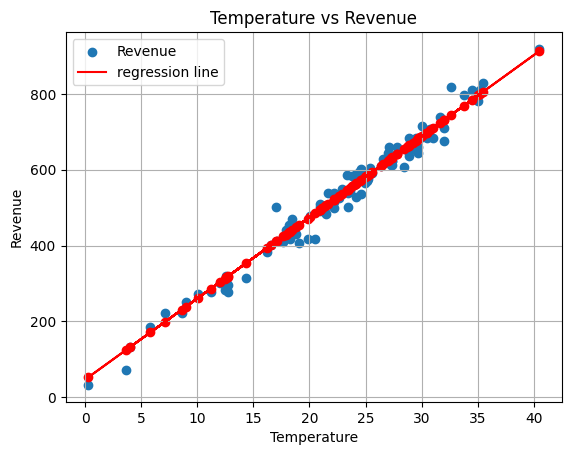

In [81]:
plt.scatter(x1_test, y1_test, label="Revenue")

# add the regression line used in train dataset
plt.plot(x1_test, y1_pred, label="regression line", color="red")
plt.scatter(x1_test, y1_pred, color="red")

plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.title("Temperature vs Revenue")
plt.grid()
plt.legend()

In [82]:
# Que. 3
# In the following dataset you have given SAT score and GPA of students. You have to predict GPA of students by using SAT score.
# Build a Linear Regression Model and plot regression line.

# Dataset : SAT-GPA.csv

In [83]:
df3 = pd.read_csv("SAT-GPA.csv")
df3.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [84]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     84 non-null     int64  
 1   GPA     84 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4 KB


In [85]:
df3.describe()

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


In [86]:
df3.corr()

,SAT,GPA
SAT,1.000000,0.637184
GPA,0.637184,1.000000


In [87]:
x1=df3.drop('GPA',axis=1)
y1=df3['GPA']

In [88]:
from sklearn.model_selection import train_test_split
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,train_size=0.8,random_state=42)

In [89]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x1_train,y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [90]:
y1_pred = model.predict(x1_test)

In [91]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# predict all the training set values
y1_pred_train = model.predict(x1_train)

# calculate all the evaluation metrics
mae_train = mean_absolute_error(y1_train, y1_pred_train)
mape_train = mean_absolute_percentage_error(y1_train, y1_pred_train)
mse_train = mean_squared_error(y1_train, y1_pred_train)
rmse_train = root_mean_squared_error(y1_train, y1_pred_train)
r2_train = r2_score(y1_train, y1_pred_train)

print(f"mean absolute error: {mae_train:.2f}")
print(f"mean absolute percentage error: {mape_train:.2f}")
print(f"mean squared error: {mse_train:.2f}")
print(f"root mean squared error: {rmse_train:.2f}")
print(f"r2 score: {r2_train:.2f}")

mean absolute error: 0.15
mean absolute percentage error: 0.05
mean squared error: 0.04
root mean squared error: 0.20
r2 score: 0.37


In [92]:
# predict all the training set values
y1_pred = model.predict(x1_test)

# calculate all the evaluation metrics
mae_test = mean_absolute_error(y1_test, y1_pred)
mape_test = mean_absolute_percentage_error(y1_test, y1_pred)
mse_test = mean_squared_error(y1_test, y1_pred)
rmse_test = root_mean_squared_error(y1_test, y1_pred)
r2_test = r2_score(y1_test, y1_pred)

print(f"mean absolute error: {mae_test:.2f}")
print(f"mean absolute percentage error: {mape_test:.2f}")
print(f"mean squared error: {mse_test:.2f}")
print(f"root mean squared error: {rmse_test:.2f}")
print(f"r2 score: {r2_test:.2f}")

mean absolute error: 0.16
mean absolute percentage error: 0.05
mean squared error: 0.05
root mean squared error: 0.23
r2 score: 0.47


In [93]:
report1 = pd.DataFrame({
    "MAE": [mae_train, mae_test],
    "MAPE": [mape_train, mape_test],
    "MSE": [mse_train, mse_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
}, index=["Training", "Testing"])
report1

,MAE,MAPE,MSE,RMSE,R2
Training,0.153240,0.047575,0.041485,0.203680,0.368697
Testing,0.162688,0.054327,0.052486,0.229098,0.469492


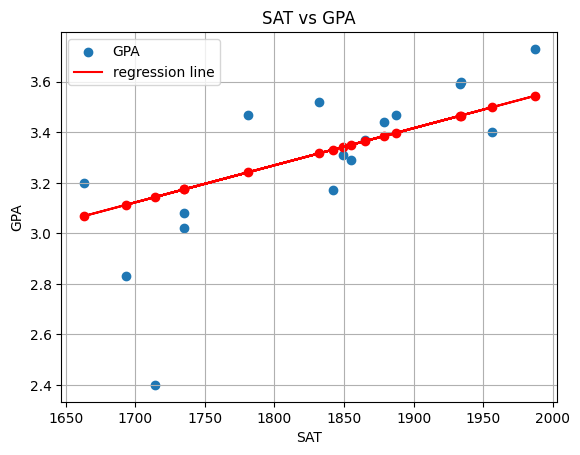

In [94]:
plt.scatter(x1_test, y1_test, label="GPA")

# add the regression line used in train dataset
plt.plot(x1_test, y1_pred, label="regression line", color="red")
plt.scatter(x1_test, y1_pred, color="red")

plt.xlabel("SAT")
plt.ylabel("GPA")
plt.title("SAT vs GPA")
plt.grid()
plt.legend()

In [95]:
# Que. 4
# Following is the description of columns in dataset ToyotaCorolla.csv. Prepare a prediction model for predicting Price.

# Model -- model of the car
# Price  -- Offer Price in EUROs	
# Age_08_04 -- Age in months as in August 2004	
# Mfg_Month -- Manufacturing month (1-12)	
# Mfg_Year	-- Manufacturing Year
# KM -- Accumulated Kilometers on odometer
# Fuel_Type	 -- Fuel Type (Petrol, Diesel, CNG)
# HP -- Horse Power
# Met_Color	 -- Metallic Color?  (Yes=1, No=0)
# Color -- Color (Blue, Red, Grey, Silver, Black, etc.)
# Automatic	-- Automatic ( (Yes=1, No=0)
# cc -- Cylinder Volume in cubic centimeters
# Doors -- Number of doors
# Cylinders	-- Number of cylinders
# Gears -- Number of gear positions
# Quarterly_Tax -- Quarterly road tax in EUROs
# Weight -- Weight in Kilograms
# Mfr_Guarantee -- Within Manufacturer's Guarantee period  (Yes=1, No=0)
# BOVAG_Guarantee -- BOVAG (Dutch dealer network) Guarantee  (Yes=1, No=0)
# Guarantee_Period -- 	Guarantee period in months
# ABS -- Anti-Lock Brake System (Yes=1, No=0)
# Airbag_1 -- Driver_Airbag  (Yes=1, No=0)
# Airbag_2 -- Passenger Airbag  (Yes=1, No=0)
# Airco -- Airconditioning  (Yes=1, No=0)
# Automatic_airco -- Automatic Airconditioning  (Yes=1, No=0)
# Boardcomputer -- Boardcomputer  (Yes=1, No=0)
# CD_Player -- CD Player  (Yes=1, No=0)
# Central_Lock -- Central Lock  (Yes=1, No=0)
# Powered_Windows -- Powered Windows  (Yes=1, No=0)
# Power_Steering -- Power Steering  (Yes=1, No=0)
# Radio -- Radio  (Yes=1, No=0)
# Mistlamps	-- Mistlamps  (Yes=1, No=0)
# Sport_Model -- Sport Model  (Yes=1, No=0)
# Backseat_Divider -- Backseat Divider  (Yes=1, No=0)
# Metallic_Rim --Metallic Rim  (Yes=1, No=0)
# Radio_cassette -- Radio Cassette  (Yes=1, No=0)
# Tow_Bar -- Tow Bar  (Yes=1, No=0)

# Consider below columns for prdecting the price.
# ("Age_08_04","KM","HP","cc","Doors","Gears","Quarterly_Tax","Weight")

In [97]:
df4=pd.read_csv('ToyotaCorolla.csv',encoding='latin1')
df4.head(2)

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,1,0,0,0,1,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,1,0,1,0,0,0,1,0,0,0


In [98]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Id                1436 non-null   int64
 1   Model             1436 non-null   str  
 2   Price             1436 non-null   int64
 3   Age_08_04         1436 non-null   int64
 4   Mfg_Month         1436 non-null   int64
 5   Mfg_Year          1436 non-null   int64
 6   KM                1436 non-null   int64
 7   Fuel_Type         1436 non-null   str  
 8   HP                1436 non-null   int64
 9   Met_Color         1436 non-null   int64
 10  Color             1436 non-null   str  
 11  Automatic         1436 non-null   int64
 12  cc                1436 non-null   int64
 13  Doors             1436 non-null   int64
 14  Cylinders         1436 non-null   int64
 15  Gears             1436 non-null   int64
 16  Quarterly_Tax     1436 non-null   int64
 17  Weight            1436 non-null   int64
 18 

In [99]:
df4.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,cc,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.580084,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.493717,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [102]:
df4.drop(['Model','Fuel_Type','Color'],axis=1,inplace=True)

In [103]:
df4.corr()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,cc,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
Id,1.000000,-0.738250,0.906132,0.043742,-0.919523,0.273298,-0.109375,-0.079713,0.066265,-0.117704,...,-0.238940,-0.236723,-0.091587,-0.010971,-0.139708,-0.028704,-0.136398,-0.022232,-0.011611,0.159171
Price,-0.738250,1.000000,-0.876590,-0.018138,0.885159,-0.569960,0.314990,0.108905,0.033081,0.126389,...,0.343458,0.356518,0.064275,-0.041887,0.222083,0.164121,0.102569,0.108564,-0.043179,-0.172369
Age_08_04,0.906132,-0.876590,1.000000,-0.123255,-0.983661,0.505672,-0.156622,-0.108150,0.031717,-0.098084,...,-0.279631,-0.283856,-0.069192,0.013791,-0.126895,-0.110988,-0.116751,-0.040045,0.012857,0.188720
Mfg_Month,0.043742,-0.018138,-0.123255,1.000000,-0.057416,-0.020630,-0.039312,0.030266,0.009146,0.037387,...,0.010055,0.025185,-0.055495,0.031601,-0.033504,0.052789,0.023245,0.023506,0.032576,-0.042170
Mfg_Year,-0.919523,0.885159,-0.983661,-0.057416,1.000000,-0.504974,0.164697,0.103310,-0.033567,0.091892,...,0.279490,0.280996,0.079676,-0.019607,0.133737,0.102080,0.113237,0.036022,-0.018844,-0.182206
KM,0.273298,-0.569960,0.505672,-0.020630,-0.504974,1.000000,-0.333538,-0.080503,-0.081854,0.102683,...,-0.125177,-0.156242,0.007397,0.013661,-0.074327,-0.044784,-0.045658,-0.013599,0.015770,0.084153
HP,-0.109375,0.314990,-0.156622,-0.039312,0.164697,-0.333538,1.000000,0.058712,0.013144,0.035856,...,0.250122,0.265593,0.048850,0.020998,0.210571,-0.006027,0.010908,0.206784,0.019919,0.068271
Met_Color,-0.079713,0.108905,-0.108150,0.030266,0.103310,-0.080503,0.058712,1.000000,-0.019335,0.031812,...,0.153307,0.145147,0.086544,0.072756,0.023821,0.003779,0.037741,0.053829,0.071530,0.148536
Automatic,0.066265,0.033081,0.031717,0.009146,-0.033567,-0.081854,0.013144,-0.019335,1.000000,0.066740,...,-0.002502,-0.005864,-0.004469,-0.014600,0.003077,0.013175,-0.018876,-0.078095,-0.014150,0.018786
cc,-0.117704,0.126389,-0.098084,0.037387,0.091892,0.102683,0.035856,0.031812,0.066740,1.000000,...,0.072634,0.055299,0.032933,-0.000361,0.017326,-0.035195,-0.055711,0.003236,-0.000470,0.002725


In [104]:
df4.isna().sum()

Id                  0
Price               0
Age_08_04           0
Mfg_Month           0
Mfg_Year            0
KM                  0
HP                  0
Met_Color           0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Quarterly_Tax       0
Weight              0
Mfr_Guarantee       0
BOVAG_Guarantee     0
Guarantee_Period    0
ABS                 0
Airbag_1            0
Airbag_2            0
Airco               0
Automatic_airco     0
Boardcomputer       0
CD_Player           0
Central_Lock        0
Powered_Windows     0
Power_Steering      0
Radio               0
Mistlamps           0
Sport_Model         0
Backseat_Divider    0
Metallic_Rim        0
Radio_cassette      0
Tow_Bar             0
dtype: int64

In [105]:
df4['Cylinders']

0       4
1       4
2       4
3       4
4       4
       ..
1431    4
1432    4
1433    4
1434    4
1435    4
Name: Cylinders, Length: 1436, dtype: int64

In [109]:
x1=df4[["Age_08_04","KM","HP","cc","Doors","Gears","Quarterly_Tax","Weight"]]
y1=df4['Price']

In [110]:
from sklearn.model_selection import train_test_split
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,train_size=0.8,random_state=42)


In [111]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x1_train,y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [112]:
y1_pred = model.predict(x1_test)

In [113]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# predict all the training set values
y1_pred_train = model.predict(x1_train)

# calculate all the evaluation metrics
mae_train = mean_absolute_error(y1_train, y1_pred_train)
mape_train = mean_absolute_percentage_error(y1_train, y1_pred_train)
mse_train = mean_squared_error(y1_train, y1_pred_train)
rmse_train = root_mean_squared_error(y1_train, y1_pred_train)
r2_train = r2_score(y1_train, y1_pred_train)

print(f"mean absolute error: {mae_train:.2f}")
print(f"mean absolute percentage error: {mape_train:.2f}")
print(f"mean squared error: {mse_train:.2f}")
print(f"root mean squared error: {rmse_train:.2f}")
print(f"r2 score: {r2_train:.2f}")

mean absolute error: 993.69
mean absolute percentage error: 0.10
mean squared error: 1761267.09
root mean squared error: 1327.13
r2 score: 0.87


In [114]:
# predict all the training set values
y1_pred = model.predict(x1_test)

# calculate all the evaluation metrics
mae_test = mean_absolute_error(y1_test, y1_pred)
mape_test = mean_absolute_percentage_error(y1_test, y1_pred)
mse_test = mean_squared_error(y1_test, y1_pred)
rmse_test = root_mean_squared_error(y1_test, y1_pred)
r2_test = r2_score(y1_test, y1_pred)

print(f"mean absolute error: {mae_test:.2f}")
print(f"mean absolute percentage error: {mape_test:.2f}")
print(f"mean squared error: {mse_test:.2f}")
print(f"root mean squared error: {rmse_test:.2f}")
print(f"r2 score: {r2_test:.2f}")

mean absolute error: 995.59
mean absolute percentage error: 0.10
mean squared error: 1950244.99
root mean squared error: 1396.51
r2 score: 0.85


In [115]:
report1 = pd.DataFrame({
    "MAE": [mae_train, mae_test],
    "MAPE": [mape_train, mape_test],
    "MSE": [mse_train, mse_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
}, index=["Training", "Testing"])
report1

,MAE,MAPE,MSE,RMSE,R2
Training,993.685587,0.099351,1.761267e+06,1327.127384,0.865485
Testing,995.586385,0.099974,1.950245e+06,1396.511721,0.853835


In [116]:
#Que. 5

# Refer the “Engine.csv” and observe the dataset and decide type of Regression.
# Datasets provide fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada.
# Predict the Co2emission for with given fuel consumption ratings CYLINDERS, ENGINESIZE, FUELCONSUMPTION_COMB.

In [117]:
df5=pd.read_csv('Engine.csv')
df5.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


In [118]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ENGINESIZE            1067 non-null   float64
 1   CYLINDERS             1067 non-null   int64  
 2   FUELCONSUMPTION_COMB  1067 non-null   float64
 3   CO2EMISSIONS          1067 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 33.5 KB


In [119]:
df5.describe()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
count,1067.000000,1067.000000,1067.000000,1067.000000
mean,3.346298,5.794752,11.580881,256.228679
std,1.415895,1.797447,3.485595,63.372304
min,1.000000,3.000000,4.700000,108.000000
25%,2.000000,4.000000,9.000000,207.000000
50%,3.400000,6.000000,10.900000,251.000000
75%,4.300000,8.000000,13.350000,294.000000
max,8.400000,12.000000,25.800000,488.000000


In [120]:
df5.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.819482,0.874154
CYLINDERS,0.934011,1.000000,0.776788,0.849685
FUELCONSUMPTION_COMB,0.819482,0.776788,1.000000,0.892129
CO2EMISSIONS,0.874154,0.849685,0.892129,1.000000


In [122]:
x1=df5.drop('CO2EMISSIONS',axis=1)
y1=df5['CO2EMISSIONS']

In [123]:
from sklearn.model_selection import train_test_split
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,train_size=0.8,random_state=42)

In [124]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x1_train,y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [125]:
y1_pred = model.predict(x1_test)

In [126]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# predict all the training set values
y1_pred_train = model.predict(x1_train)

# calculate all the evaluation metrics
mae_train = mean_absolute_error(y1_train, y1_pred_train)
mape_train = mean_absolute_percentage_error(y1_train, y1_pred_train)
mse_train = mean_squared_error(y1_train, y1_pred_train)
rmse_train = root_mean_squared_error(y1_train, y1_pred_train)
r2_train = r2_score(y1_train, y1_pred_train)

print(f"mean absolute error: {mae_train:.2f}")
print(f"mean absolute percentage error: {mape_train:.2f}")
print(f"mean squared error: {mse_train:.2f}")
print(f"root mean squared error: {rmse_train:.2f}")
print(f"r2 score: {r2_train:.2f}")

mean absolute error: 16.98
mean absolute percentage error: 0.07
mean squared error: 554.30
root mean squared error: 23.54
r2 score: 0.86


In [127]:
# predict all the training set values
y1_pred = model.predict(x1_test)

# calculate all the evaluation metrics
mae_test = mean_absolute_error(y1_test, y1_pred)
mape_test = mean_absolute_percentage_error(y1_test, y1_pred)
mse_test = mean_squared_error(y1_test, y1_pred)
rmse_test = root_mean_squared_error(y1_test, y1_pred)
r2_test = r2_score(y1_test, y1_pred)

print(f"mean absolute error: {mae_test:.2f}")
print(f"mean absolute percentage error: {mape_test:.2f}")
print(f"mean squared error: {mse_test:.2f}")
print(f"root mean squared error: {rmse_test:.2f}")
print(f"r2 score: {r2_test:.2f}")

mean absolute error: 16.72
mean absolute percentage error: 0.07
mean squared error: 512.86
root mean squared error: 22.65
r2 score: 0.88


In [128]:
report1 = pd.DataFrame({
    "MAE": [mae_train, mae_test],
    "MAPE": [mape_train, mape_test],
    "MSE": [mse_train, mse_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
}, index=["Training", "Testing"])
report1

,MAE,MAPE,MSE,RMSE,R2
Training,16.980181,0.065628,554.302383,23.543627,0.860596
Testing,16.721594,0.070082,512.855137,22.646305,0.875971
